# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
| Group           | 67       |
|-----------------|----------|
| Kazuki Udagawa  | 6169872  |
| Jonah Wilthagen | 6270816  |
| Mauk van 't Hof | 6261000  |
| Satsuki Udagawa | 5747317  |

#### Imports

In [113]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [114]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        return random.choice(agent.get_valid_actions(maze))

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        state = agent.get_state(maze)
        actions = agent.get_valid_actions(maze)

        # Decide between exploration and exploitation
        explore = np.random.random() < eps

        if explore:
            return random.choice(actions)

        # Compute Q-values for all valid actions
        q_vals = {action: self.q_table.get_q(state, action) for action in actions}

        # Find the maximum Q-value
        max_q = max(q_vals.values())

        # Select all actions that share the maximum Q-value
        best = [a for a, q in q_vals.items() if q == max_q]

        # Break ties randomly
        return random.choice(best)

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        current_state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)
        
        # Compute Boltzmann probabilities
        q_values = [self.q_table.get_q(current_state, action) for action in valid_actions]
        exp_q_values = np.exp(np.array(q_values) / temperature)
        probabilities = exp_q_values / np.sum(exp_q_values)
        
        # Choose an action based on the Boltzmann probabilities
        sum_exp = np.sum(exp_q_values)
        probabilities = exp_q_values / sum_exp

        selected_action = np.random.choice(valid_actions, p=probabilities)
        
        return selected_action


In [115]:
# TESTS

# create a small 2x2 maze manually
def create_test_maze():
    maze = Maze.__new__(Maze)  # bypass __init__
    maze.width = 2
    maze.height = 2
    maze.states = {
        0: {0: State(0, 0, 0, "path"), 1: State(1, 1, 0, "path")},
        1: {0: State(2, 0, 1, "wall"), 1: State(3, 1, 1, "path")}
    }
    maze.rewards = {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}}
    return maze

# create an agent at starting position
def create_test_agent():
    return Agent(start_x=0, start_y=0)

# create a Q-table for all actions
def create_test_qtable(maze):
    actions = [Action("up"), Action("down"), Action("left"), Action("right")]
    states = [s for row in maze.states.values() for s in row.values()]
    return QTable(states, actions)

test_maze = create_test_maze()
agent_test = create_test_agent()
q_table_test = create_test_qtable(test_maze)
strategy_test = ExplorationStrategy(q_table_test)

#Test random strategy
action_test = strategy_test.random(agent_test, test_maze)
valid_action_ids = [a.id for a in agent_test.get_valid_actions(test_maze)]
assert action_test.id in valid_action_ids, f"Random action {action_test.id} must be valid"

#Test e-greedy strategy
for _ in range(10):
    action = strategy_test.e_greedy(agent_test, test_maze, eps=0.5)
    valid_action_ids = [a.id for a in agent_test.get_valid_actions(test_maze)]
    assert action.id in valid_action_ids, f"E-greedy action {action.id} must be valid"

#Test boltzmann strategy
for _ in range(10):
    action = strategy.boltzmann(agent, test_maze, temperature=1.0)
    valid_action_ids = [a.id for a in agent.get_valid_actions(test_maze)]
    assert action.id in valid_action_ids, f"Boltzmann action {action.id} must be valid"

print("All basic exploration strategy tests passed!")

All basic exploration strategy tests passed!


The random() method selects a random action from the set of all valid actions at uniformly distributed probabilities. This strategy allows the agent to explore the environment without any bias and the agent can discover different parts of the maze at equal probabilities. 

The e_greedy() method is the implementation of the epsilon-greedy exploration strategy. In this strategy, the agent chooses to take a random action (exploration) with probability epsilon and the action with the highest Q-value (exploitation) with probability 1 - epsilon. The initial selection of the value of the hyper-parameter epsilon determines how likely the agent will take each of the two actions. A higher epsilon value means the agent is more likely to explore, and a lower epsilon means the agent is more likely to exploit, or use already acquired knowledge in its decisions.

The boltzmann() method implements the Boltzmann exploration strategy. Here, each action is assigned a probability based on its estimated Q-value in the Q-table. The hyper-parameter temperature determines how likely it is for the agent to either explore or exploit. A higher temperature makes the agent more likely to explore, while a lower temperature makes it more likely for the agent to exploit. 

To ensure sufficient exploration, we should use a higher value of epsilon during the earlier stages of learning to ensure the exploration of various actions and prevent getting stuck in a set of sub-optimal actions. For similar reasons, the temperature should also be higher in the earlier stages of learning. As learning progresses, both hyper-parameters should gradually decrease to shift towards exploitation. This way, we can be sure that the agent explores the maze effectively and gradually shifts towards exploitation as its knowledge increases. 

#### Question 2

In [116]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)

# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []

for episode in tqdm(range(n_episodes)):
    pass

# Global variable for maximum steps per episode
max_steps_per_episode = 1000

def agent_cycle(agent, exploration_strategy, maze, max_steps):
    rewards_per_episode = []
    steps_taken = 0

    # Continue running episodes until max steps is reached
    while steps_taken < max_steps:

        # Track reward earned in the current episode
        episode_total = 0
        state = agent.get_state(maze)

        # Episode loop: continue until terminal state or per-episode step cap
        episode_steps = 0
        while not state.done and episode_steps < max_steps_per_episode:

            # Select an action using the chosen exploration method
            action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

            # Apply the action and observe the outcome
            next_state, reward, finished = agent.step(action, maze)
            episode_total += reward
            
            # Transition to the next state or reset if episode ends
            if finished:
                agent.reset()
                state = agent.get_state(maze)
            else:
                state = next_state

            # Update counters
            episode_steps += 1
            steps_taken += 1

        # Store the reward accumulated in this episode
        rewards_per_episode.append(episode_total)

    return rewards_per_episode


100%|██████████| 300/300 [00:00<00:00, 465344.38it/s]


In [117]:
# TESTS

# create a small 2x2 maze manually
def create_tiny_maze():
    maze = Maze.__new__(Maze)  # bypass __init__
    maze.width = 2
    maze.height = 2
    maze.states = {
        0: {0: State(0, 0, 0, "path"), 1: State(1, 1, 0, "path")},
        1: {0: State(2, 0, 1, "wall"), 1: State(3, 1, 1, "path")}
    }
    maze.rewards = {0:{0:0,1:0},1:{0:0,1:0}}
    maze.set_reward = lambda x,y,r: maze.rewards.__setitem__(y,{**maze.rewards[y],x:r})
    maze.get_reward = lambda x,y: maze.rewards[y][x]
    maze.set_terminal = lambda x,y: setattr(maze.get_state(x,y),'done',True)
    return maze

# setup agent, Q-table, exploration strategy
test_maze = create_tiny_maze()
test_maze.set_reward(1,1,10)
test_maze.set_terminal(1,1)
agent_test = Agent(start_x=0, start_y=0)
actions_test = [Action(id) for id in ["up","down","left","right"]]
q_table_test = QTable(test_maze.get_all_states(), actions_test)
exploration_strategy_test = ExplorationStrategy(q_table_test)

# agent_cycle
def agent_cycle_test(agent, strategy, maze, max_steps):
    rewards_per_episode = []
    steps_taken = 0
    max_steps_per_episode = 5  # tiny per-episode limit

    while steps_taken < max_steps:
        episode_total = 0
        state = agent.get_state(maze)
        episode_steps = 0
        while not state.done and episode_steps < max_steps_per_episode:
            action = strategy.e_greedy(agent, maze, eps=0.1)
            next_state, reward, finished = agent.step(action, maze)
            episode_total += reward
            if finished:
                agent.reset()
                state = agent.get_state(maze)
            else:
                state = next_state
            episode_steps += 1
            steps_taken += 1
        rewards_per_episode.append(episode_total)
    return rewards_per_episode

# test agent cycle
rewards_test = agent_cycle_test(agent, exploration_strategy, test_maze, max_steps=10)
assert isinstance(rewards_test, list), "Rewards should be a list"
assert all(isinstance(r,(int,float)) for r in rewards_test), "All rewards must be numbers"
print("All agent exploration tests passed!")

All agent exploration tests passed!


We implemented the agent’s cycle in the agent_cycle() method. This method takes an Agent instance, an ExplorationStrategy, a Maze, and a hyperparameter max_steps. For each cycle, we repeat the following steps until the maximum number of steps is reached:

- We begin each episode by resetting the agent and obtaining the current state. Then, until we reach a terminal state or the episode step cap, we select an action using the chosen exploration strategy, execute the action, and observe the resulting next state and reward. If the episode ends, we reset the agent. Otherwise, we continue from the new state.

- After each episode, we store the accumulated reward in rewards_per_episode, and once all episodes have finished, we return this list. 

At this stage, these steps are all we need because the actual learning updates will be added later in the learn() methods. Once learning is implemented, the same cycle will incorporate Q‑value updates without requiring any additional steps. 

#### Question 3

In [118]:
max_steps_test = 30000
episode_rewards = agent_cycle(agent, exploration_strategy, maze, max_steps_test)

# Confirm that the stopping condition was triggered by the global step cap
if len(episode_rewards) * max_steps_per_episode >= max_steps_test:
    print("Training ran as intended when max steps was reached.")
else:
    print("Warning: The run ended before reaching the maximum steps.")

Training ran as intended when max steps was reached.


We verified the stopping criterion by running the agent with a global step limit of 30 000 and checking whether the run terminated exactly when this limit was reached. After the run, we compared the number of completed episodes multiplied by the maximum steps per episode to the global step cap. The condition evaluated to true, confirming that the agent stopped because the total number of steps exceeded 30 000.

#### Question 4

100%|██████████| 10/10 [00:01<00:00,  6.17it/s]


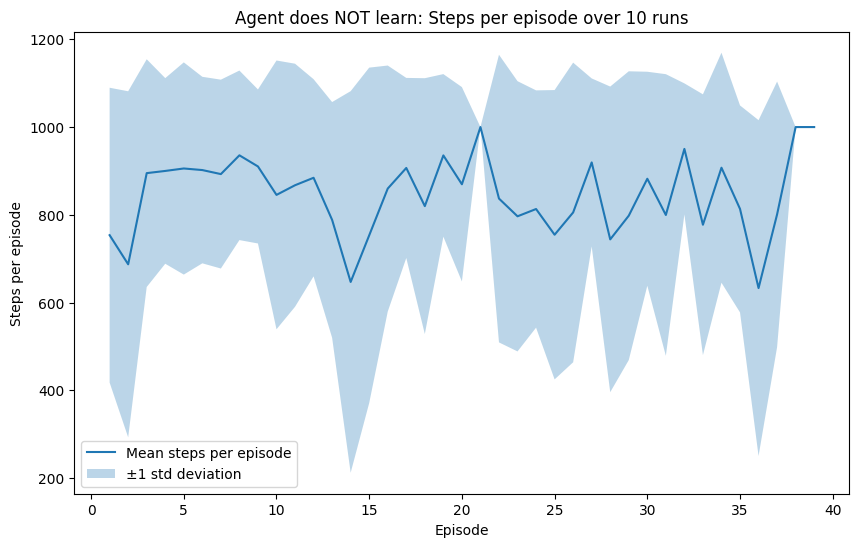

In [119]:
# Run a training run and return steps per episode 
def run_single(agent, exploration_strategy, maze, max_steps_total):
    steps_per_episode = []
    steps_taken = 0

    while steps_taken < max_steps_total:
        state = agent.get_state(maze)
        episode_steps = 0

        while not state.done and episode_steps < max_steps_per_episode:
            action = exploration_strategy.e_greedy(agent, maze, eps=0.1)
            next_state, reward, finished = agent.step(action, maze)

            episode_steps += 1
            steps_taken += 1

            if finished:
                agent.reset()
                break
            else:
                state = next_state

        steps_per_episode.append(episode_steps)

    return steps_per_episode


# Run 10 runs and align episode lengths
def run_multiple(agent, exploration_strategy, maze, n_runs=10, max_steps_total=30000):
    all_runs = []

    for _ in tqdm(range(n_runs)):
        agent.reset()
        steps = run_single(agent, exploration_strategy, maze, max_steps_total)
        all_runs.append(steps)

    # Align runs by padding with NaN
    max_len = max(len(run) for run in all_runs)
    aligned = np.array([run + [np.nan]*(max_len - len(run)) for run in all_runs])

    return aligned


# Run experiments and analyze results
aligned_steps = run_multiple(agent, exploration_strategy, maze)
mean_steps = np.nanmean(aligned_steps, axis=0)
std_steps = np.nanstd(aligned_steps, axis=0)
episodes = np.arange(1, len(mean_steps) + 1)

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_steps, label="Mean steps per episode")
plt.fill_between(episodes,
                 mean_steps - std_steps,
                 mean_steps + std_steps,
                 alpha=0.3,
                 label="±1 std deviation")

plt.xlabel("Episode")
plt.ylabel("Steps per episode")
plt.title("Agent does NOT learn: Steps per episode over 10 runs")
plt.legend()
plt.show()

In [120]:
# TESTS

# create a small 2x2 maze manually
def create_tiny_maze():
    maze = Maze.__new__(Maze)
    maze.width = 2
    maze.height = 2
    maze.states = {
        0: {0: State(0, 0, 0, "path"), 1: State(1, 1, 0, "path")},
        1: {0: State(2, 0, 1, "wall"), 1: State(3, 1, 1, "path")}
    }
    maze.rewards = {0:{0:0,1:0},1:{0:0,1:0}}
    maze.set_reward = lambda x,y,r: maze.rewards.__setitem__(y,{**maze.rewards[y],x:r})
    maze.get_reward = lambda x,y: maze.rewards[y][x]
    maze.set_terminal = lambda x,y: setattr(maze.get_state(x,y),'done',True)
    return maze

# setup agent, actions, q-table, exploration
test_maze = create_tiny_maze()
test_maze.set_reward(1,1,10)
test_maze.set_terminal(1,1)
agent_test = Agent(start_x=0, start_y=0)
actions_test = [Action(id) for id in ["up","down","left","right"]]
q_table_test = QTable(test_maze.get_all_states(), actions_test)
exploration_strategy_test = ExplorationStrategy(q_table_test)
max_steps_per_episode = 5  # keep episodes short for tests

# test function: single run
def run_single(agent, strategy, maze, max_steps_total):
    steps_per_episode = []
    steps_taken = 0

    while steps_taken < max_steps_total:
        state = agent.get_state(maze)
        episode_steps = 0

        while not state.done and episode_steps < max_steps_per_episode:
            action = strategy.e_greedy(agent, maze, eps=0.1)
            next_state, reward, finished = agent.step(action, maze)

            episode_steps += 1
            steps_taken += 1

            if finished:
                agent.reset()
                break
            else:
                state = next_state

        steps_per_episode.append(episode_steps)

    return steps_per_episode

# test function: multiple runs
def run_multiple(agent, strategy, maze, n_runs=2, max_steps_total=20):
    all_runs = []

    for _ in tqdm(range(n_runs), desc="Fast test runs"):
        agent.reset()
        steps = run_single(agent, strategy, maze, max_steps_total)
        all_runs.append(steps)

    # Align runs by padding with NaN
    max_len = max(len(run) for run in all_runs)
    aligned = np.array([run + [np.nan]*(max_len - len(run)) for run in all_runs])
    return aligned


# run_single returns list of positive integers
single_steps_test = run_single(agent_test, exploration_strategy_test, test_maze, max_steps_total=10)
assert isinstance(single_steps_test, list), "run_single must return a list"
assert all(isinstance(s,int) and s>0 for s in single_steps_test), "All steps must be positive integers"

# run_multiple returns a numpy array with shape (n_runs, max_len)
multi_steps_test = run_multiple(agent_test, exploration_strategy_test, test_maze, n_runs=2, max_steps_total=10)
assert isinstance(multi_steps_test, np.ndarray), "run_multiple must return a numpy array"
assert multi_steps_test.shape[0] == 2, "First dimension must equal n_runs"
assert multi_steps_test.shape[1] >= 1, "Second dimension must be at least 1 (padded to max length)"

# check that no agent steps exceed max_steps_per_episode
assert np.nanmax(multi_steps_test) <= max_steps_per_episode, "No episode should exceed max_steps_per_episode"

print("All run_single and run_multiple tests passed!")

Fast test runs: 100%|██████████| 2/2 [00:00<00:00, 3169.10it/s]

All run_single and run_multiple tests passed!


We ran the agent for 10 independent runs and recorded the number of steps taken in each episode. Because different runs may contain different numbers of episodes, we aligned them by padding shorter runs with NaN values so that the averages remain meaningful. For each episode index, we computed the mean number of steps across the 10 runs and plotted this together with a standard‑deviation band to indicate uncertainty.

The resulting plots show that the average number of steps per episode does not decrease over time. This confirms that the agent does not learn the maze at this stage, which is expected because the learning update has not yet been implemented. The standard deviation band remains wide throughout the run, although it fluctuates slightly across episodes due to randomness in the agent’s behaviour and the fact that different runs contain different numbers of episodes. This further indicates that the agent’s behaviour does not improve across episodes. Overall, the plots clearly demonstrate that the agent does not learn its environment under the current setup.

#### Question 5

In [121]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, actions: List[Action], state: State, action: Action, 
              next_state: State, reward: float, done: bool) -> None:

        alpha = self.params.get("lr", 0.7)
        gamma = self.params.get("gamma", 0.9)

        q_old = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            best_future = max(self.q_table.get_q(next_state, a) for a in actions)
            target = reward + gamma * best_future

        q_new = q_old + alpha * (target - q_old)
        self.q_table.set_q(state, action, q_new)

In [122]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
              reward: float, done: bool) -> None:

        alpha = self.params.get("lr", 0.7)
        gamma = self.params.get("gamma", 0.9)

        q_old = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            q_next = self.q_table.get_q(next_state, next_action)
            target = reward + gamma * q_next

        q_new = q_old + alpha * (target - q_old)
        self.q_table.set_q(state, action, q_new)

In [123]:
# TESTS

# create a small 2x2 maze manually
state0_test = State(0, 0, 0, "path")
state1_test = State(1, 1, 0, "path")
actions_test = [Action("up"), Action("down")]

q_table_test = QTable([state0_test, state1_test], actions_test, initial_value=0.0)

# QLearning test
ql_test = QLearning(q_table_test, {"lr":0.5, "gamma":0.9})

# Non-terminal update
ql_test.learn(actions_test, state0_test, actions_test[0], state1_test, reward=10, done=False)
updated_q_test = q_table_test.get_q(state0_test, actions_test[0])
expected_q_test = 0 + 0.5 * (10 + 0.9 * 0 - 0) 
assert np.isclose(updated_q_test, 5.0), f"QLearning non-terminal update failed: {updated_q_test}"

# Terminal update
ql_test.learn(actions_test, state0_test, actions_test[1], state1_test, reward=20, done=True)
updated_q_test = q_table_test.get_q(state0_test, actions_test[1])
expected_q_test = 20 
q_old_test = 0
alpha_test = 0.5
target_test = 20
q_new_test = q_old_test + alpha_test*(target_test-q_old_test) 
assert np.isclose(updated_q_test, 10.0), f"QLearning terminal update failed: {updated_q_test}"

# SARSA test
q_table2_test = QTable([state0_test, state1_test], actions_test, initial_value=0.0)
sarsa_test = SARSA(q_table2_test, {"lr":0.5, "gamma":0.9})

# Non-terminal update
sarsa_test.learn(state0_test, actions_test[0], state1_test, actions_test[1], reward=10, done=False)
q_old_test = 0
q_next_test = 0  
expected_q_test = q_old_test + 0.5*(10 + 0.9*q_next_test - q_old_test)
updated_q_test = q_table2_test.get_q(state0_test, actions_test[0])
assert np.isclose(updated_q_test, expected_q_test), f"SARSA non-terminal update failed: {updated_q_test}"

# Terminal update
sarsa_test.learn(state0_test, actions_test[1], state1_test, actions_test[0], reward=20, done=True)
q_old_test = 0
target_test = 20
expected_q_test = q_old_test + 0.5*(target_test-q_old_test)
updated_q_test = q_table2_test.get_q(state0_test, actions_test[1])
assert np.isclose(updated_q_test, expected_q_test), f"SARSA terminal update failed: {updated_q_test}"

print("All QLearning and SARSA learn() tests passed!")

All QLearning and SARSA learn() tests passed!



For Q‑learning, we implemented the update rule from Equation 1.1. The method retrieves the current Q‑value for the state–action pair and updates it toward the target value r+γmax⁡a′Q(s′,a′). If the next state is terminal, the target is simply the reward. The new Q‑value is computed using the learning rate α=0.7 and discount factor γ=0.9.

For SARSA, we implemented the update rule from Equation 1.2. Instead of using the maximum future Q‑value, SARSA uses the Q‑value of the actual next action selected by the policy, Q(s′,a′). As in Q‑learning, terminal states use only the immediate reward. The update again uses α=0.7 and γ=0.9.

Both methods mostly follow the same structure, using the same QTable along with identical alpha and gamma values. The only substantial difference lies in how the target value is computed: Q‑learning uses the maximum estimated future value, while SARSA uses the value of the next action actually taken under the current policy.

#### Question 6

In [124]:
def run_agent(maze, algorithm_class, epsilon, alpha, n_runs=10, n_episodes=20, show_path=False):

    all_runs = []
    awards=[]

    for _ in tqdm(range(n_runs)):

        # Fresh environment
        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(a) for a in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        explorer = ExplorationStrategy(q_table)

        learner = algorithm_class(q_table, {"lr": alpha, "gamma": 0.9})

        steps_per_episode = []

        for _ in range(n_episodes):
            path = []

            agent.reset()
            state = agent.get_state(maze)
            episode_steps = 0

            # SARSA needs next_action
            action = explorer.e_greedy(agent, maze, epsilon)

            while not state.done:
                path.append((state.y, state.x))

                next_state, reward, done = agent.step(action, maze)
                episode_steps += 1

                # Q-Learning
                if isinstance(learner, QLearning):
                    learner.learn(
                        actions,
                        state,
                        action,
                        next_state,
                        reward,
                        done
                    )
                    next_action = explorer.e_greedy(agent, maze, epsilon)

                # SARSA
                else:
                    next_action = explorer.e_greedy(agent, maze, epsilon)
                    learner.learn(
                        state,
                        action,
                        next_state,
                        next_action,
                        reward,
                        done
                    )

                state = next_state
                action = next_action

            steps_per_episode.append(episode_steps)
        if show_path:
            maze.visualize(path)
        all_runs.append(steps_per_episode)
        awards.append(maze.get_reward(state.x, state.y))

    print(awards)
    return all_runs

100%|██████████| 10/10 [00:03<00:00,  2.67it/s]


[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


100%|██████████| 10/10 [00:03<00:00,  2.74it/s]

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


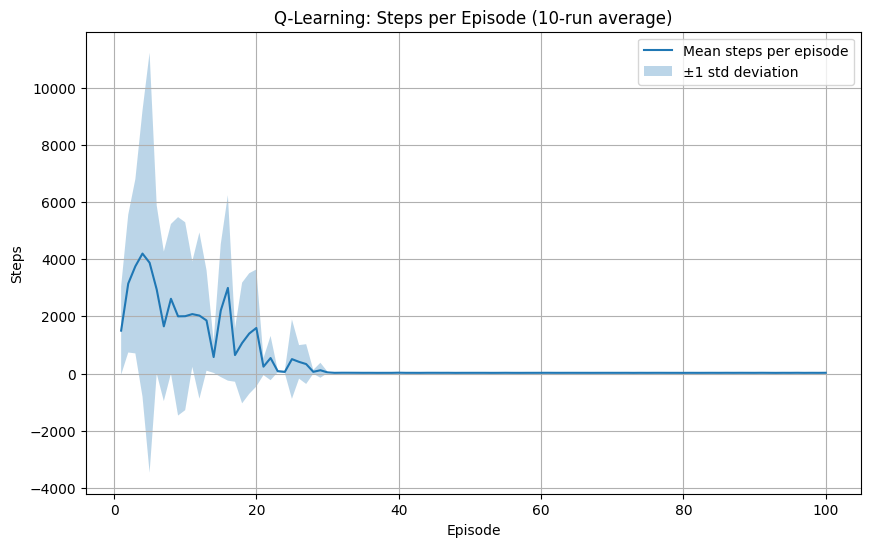

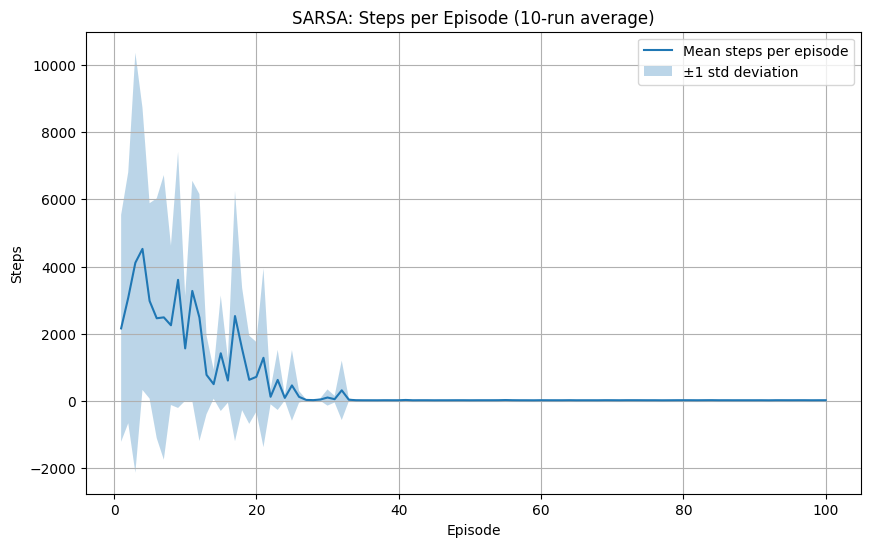

In [125]:
# Hyperparameters
n_runs = 10
n_episodes = 100
epsilon = 0.1
alpha = 0.05

# Run the agent 10 times for each algorithm
runs_q = run_agent(
    algorithm_class=QLearning,
    maze=maze,
    epsilon=epsilon,
    alpha=alpha,
    n_runs=n_runs,
    n_episodes=n_episodes
)

runs_sarsa = run_agent(
    algorithm_class=SARSA,
    maze=maze,
    epsilon=epsilon,
    alpha=alpha,
    n_runs=n_runs,
    n_episodes=n_episodes
)

# Plot Q-Learning
max_len_q = max(len(run) for run in runs_q)
aligned_q = np.array([run + [np.nan]*(max_len_q - len(run)) for run in runs_q])

mean_q = np.nanmean(aligned_q, axis=0)
std_q = np.nanstd(aligned_q, axis=0)

episodes_q = np.arange(1, len(mean_q) + 1)

plt.figure(figsize=(10, 6))
plt.plot(episodes_q, mean_q, label="Mean steps per episode")
plt.fill_between(
    episodes_q,
    mean_q - std_q,
    mean_q + std_q,
    alpha=0.3,
    label="±1 std deviation"
)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Q-Learning: Steps per Episode (10-run average)")
plt.legend()
plt.grid(True)
plt.show()

# Plot SARSA
max_len_s = max(len(run) for run in runs_sarsa)
aligned_s = np.array([run + [np.nan]*(max_len_s - len(run)) for run in runs_sarsa])

mean_s = np.nanmean(aligned_s, axis=0)
std_s = np.nanstd(aligned_s, axis=0)

episodes_s = np.arange(1, len(mean_s) + 1)

plt.figure(figsize=(10, 6))
plt.plot(episodes_s, mean_s, label="Mean steps per episode")
plt.fill_between(
    episodes_s,
    mean_s - std_s,
    mean_s + std_s,
    alpha=0.3,
    label="±1 std deviation"
)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("SARSA: Steps per Episode (10-run average)")
plt.legend()
plt.grid(True)
plt.show()

For both Q‑learning and SARSA, we ran the agent for 10 independent runs and plotted the average number of steps per episode. The learning curves show a clear downward trend. Starting from high values, the average number of steps per episode steadily decreases over the first 40-45 episodes and then stabilizes at a much lower, approximately constant level. This demonstrates that the agent is successfully learning an efficient path through the maze.

We also included a standard‑deviation band to indicate uncertainty across runs. The uncertainty is initially high because different runs explore the maze differently, but it shrinks quickly as the agent converges on the optimal policy. The narrowing band confirms that the agent’s behaviour becomes more stable and consistent over time. Together, the decreasing mean and variance show that the agent is indeed learning the environment.

#### Question 7

When comparing the learning curves of Q‑learning and SARSA, we observe the following: SARSA shows more variability in the early episodes, with a wider standard‑deviation band, but it stabilizes earlier, at around 30 episodes, after which both the mean and the uncertainty remain relatively flat. Q‑learning, on the other hand, shows slightly more fluctuation for a longer period, although the overall trend is similar. The difference in steepness between the two curves is mainly due to the different y‑axis scales, not because one learns dramatically faster.

These differences follow from the update equations. Q‑learning is off‑policy and updates toward the maximum future Q‑value, max⁡a′ Q(s′,a′), which makes it more optimistic and sometimes more inconsistent during early exploration. SARSA is on‑policy and updates toward the Q‑value of the actual next action, Q(s′,a′), which incorporates the exploration behaviour into the update. This leads to more stable learning, as seen in the smoother convergence we see in the SARSA plot.

### 2.2 Optimization
#### Question 8

100%|██████████| 10/10 [00:04<00:00,  2.42it/s]


[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


100%|██████████| 10/10 [00:04<00:00,  2.43it/s]


[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


100%|██████████| 10/10 [00:04<00:00,  2.09it/s]


...

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


100%|██████████| 10/10 [00:03<00:00,  3.25it/s]


[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


100%|██████████| 10/10 [00:43<00:00,  4.37s/it]


[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


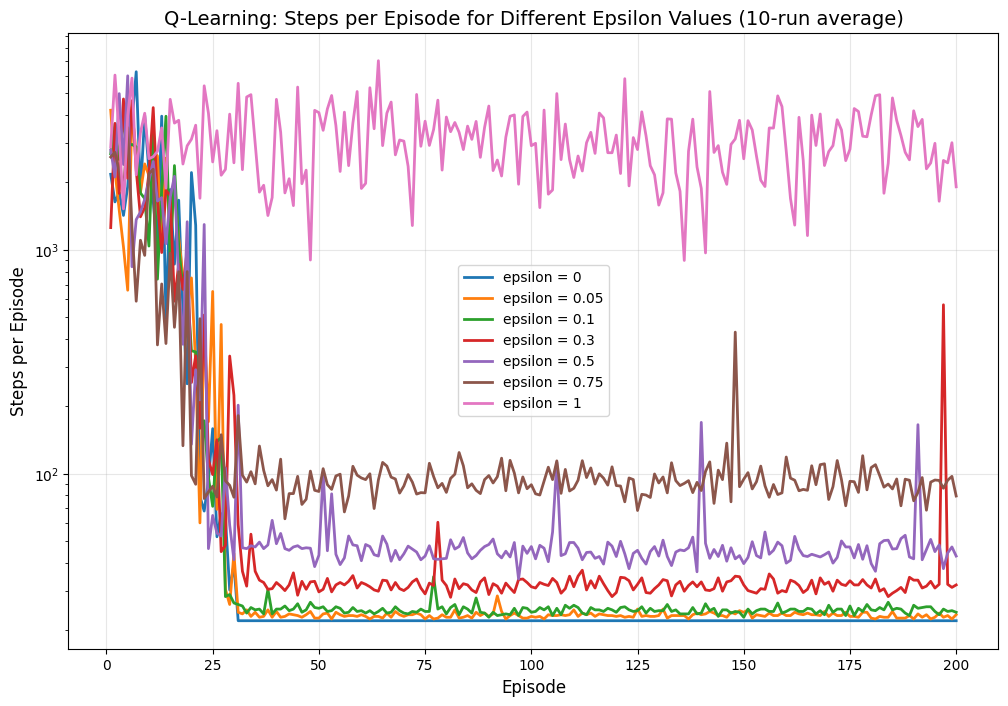

In [126]:
# Hyperparameters
n_runs = 10
n_episodes = 200
epsilon_values = [0, 0.05, 0.1, 0.3, 0.5, 0.75, 1]
alpha = 0.7

results = {}

for epsilon in epsilon_values:
    runs = run_agent(
        algorithm_class=QLearning,
        maze=maze,
        epsilon=epsilon,
        alpha=alpha,
        n_runs=n_runs,
        n_episodes=n_episodes
    )

    max_len = max(len(run) for run in runs)

    mean_steps = np.nanmean(runs, axis=0)
    std_steps = np.nanstd(runs, axis=0)

    results[epsilon] = {
        'mean': mean_steps,
        'std': std_steps,
        'episodes': np.arange(1, len(mean_steps) + 1)
    }

plt.figure(figsize=(12, 8))

for i, (epsilon, data) in enumerate(results.items()):
    plt.plot(data['episodes'], data['mean'],
             label=f"epsilon = {epsilon}",
             linewidth=2)

plt.xlabel("Episode", fontsize=12)
plt.ylabel("Steps per Episode", fontsize=12)
plt.yscale('log')
plt.title("Q-Learning: Steps per Episode for Different Epsilon Values (10-run average)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we can see, the epsilon has two effects: how quickly the learning plateaus and at what level it plateaus.

A higher epsilon means it spends more time exploring, and the learning with an epsilon of 1, is always exploring and thus never converges. Our learning with an epsilon of 0 converges very fast and stays there; it never strays. A bit counter-intuitive is that learning runs with higher epsilons (more learning) converge faster with a higher plateau; you would expect the opposite since a learning that explores more would take longer to converge on a route, but that that route has a higher chance of being. I believe that this is because we are breaking ties in actions randomly in e_greedy, and at the start all steps are the same (0). This means that no matter the epsilon, the learning will do some random exploration until it reaches the goal once.

#### Question 9

A higher epsilon means the learning process spends more time exploring, which means it tries more routes. This means it will take longer for the process to converge on a route, but the route will generally be more optimal. A lower epsilon means the learning process will converge on a route faster, but this route has a lower chance of being fully optimal.

#### Question 10

In [127]:
def run_agent_boltzmann(algorithm_class, maze, temperature, n_runs=10, n_episodes=200):

    all_runs = []

    for _ in range(n_runs):

        # Fresh environment
        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(a) for a in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        explorer = ExplorationStrategy(q_table)

        learner = algorithm_class(q_table, {"lr": alpha, "gamma": 0.9})

        steps_per_episode = []

        for _ in range(n_episodes):

            agent.reset()
            state = agent.get_state(maze)
            episode_steps = 0

            # SARSA needs next_action
            action = explorer.boltzmann(agent, maze, temperature)

            while not state.done:

                next_state, reward, done = agent.step(action, maze)
                episode_steps += 1

                learner.learn(
                    actions,
                    state,
                    action,
                    next_state,
                    reward,
                    done
                )
                next_action = explorer.boltzmann(agent, maze, temperature)

                state = next_state
                action = next_action

            steps_per_episode.append(episode_steps)

        all_runs.append(steps_per_episode)

    return all_runs


100%|██████████| 5/5 [04:04<00:00, 48.85s/it]


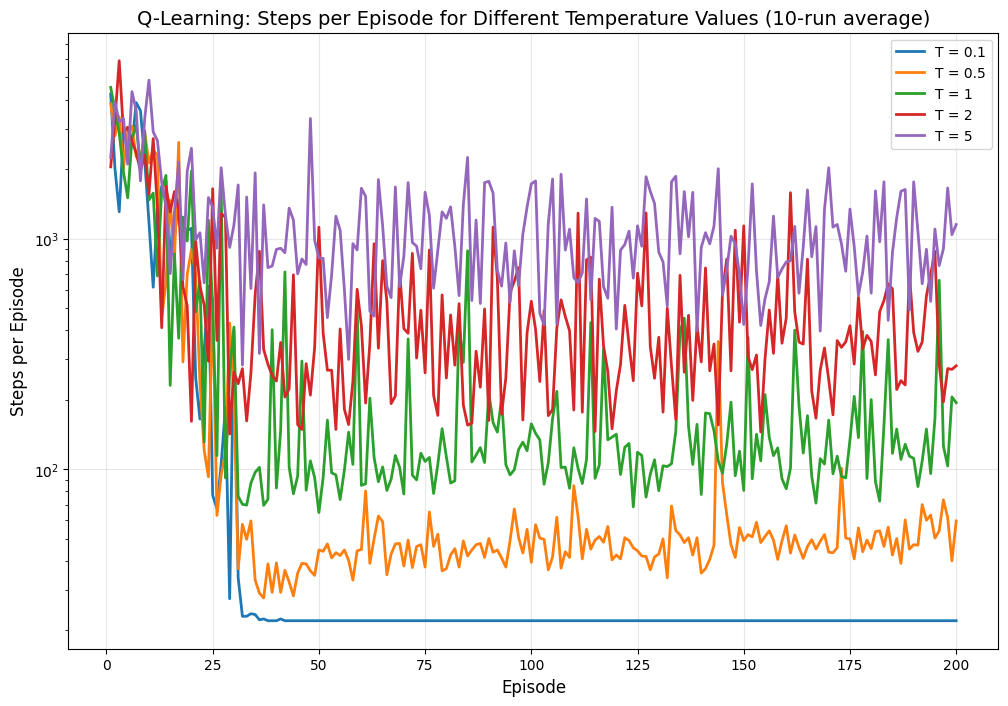

In [128]:
# Hyperparameters
n_runs = 10
n_episodes = 200
temperature_values = [0.1, 0.5, 1, 2, 5]

results = {}

for temperature in tqdm(temperature_values):
    runs = run_agent_boltzmann(
        algorithm_class=QLearning,
        maze=maze,
        temperature=temperature,
        n_runs=n_runs,
        n_episodes=n_episodes
    )

    max_len = max(len(run) for run in runs)

    mean_steps = np.nanmean(runs, axis=0)
    std_steps = np.nanstd(runs, axis=0)

    results[temperature] = {
        'mean': mean_steps,
        'std': std_steps,
        'episodes': np.arange(1, len(mean_steps) + 1)
    }

plt.figure(figsize=(12, 8))

for i, (temperature, data) in enumerate(results.items()):
    plt.plot(data['episodes'], data['mean'],
             label=f"T = {temperature}",
             linewidth=2)

plt.xlabel("Episode", fontsize=12)
plt.ylabel("Steps per Episode", fontsize=12)
plt.yscale('log')
plt.title("Q-Learning: Steps per Episode for Different Temperature Values (10-run average)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we can see, a lower temperature converges to an optimal route quickly, while a higher temperature explores more and is thus noisier. A higher temperature decreases the chances the next action with the highest rewards is chosen, which makes it noisier. Again, a low temperature still converges since it has to explore randomly at the start since all actions are equal.

#### Question 11

Random obviously isn't the best; it will never converge on anything.

Low temperature Boltzmann and low temperature e_greedy are essentially identical, both converging to the same route length in the same amount of episodes. I think we can thus conclude that very high exploitation works well in this specific scenario since random exploration is enforced initially anyway.

Since there isn't a significant difference between e_greedy or boltzmann, I would decide on e_greedy for speed.

#### Question 12

 12%|█▎        | 1/8 [00:05<00:36,  5.18s/it]

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


 25%|██▌       | 2/8 [00:08<00:26,  4.33s/it]

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


 38%|███▊      | 3/8 [00:12<00:20,  4.11s/it]

...

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


 88%|████████▊ | 7/8 [00:28<00:03,  3.96s/it]

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


100%|██████████| 8/8 [00:31<00:00,  3.98s/it]


[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


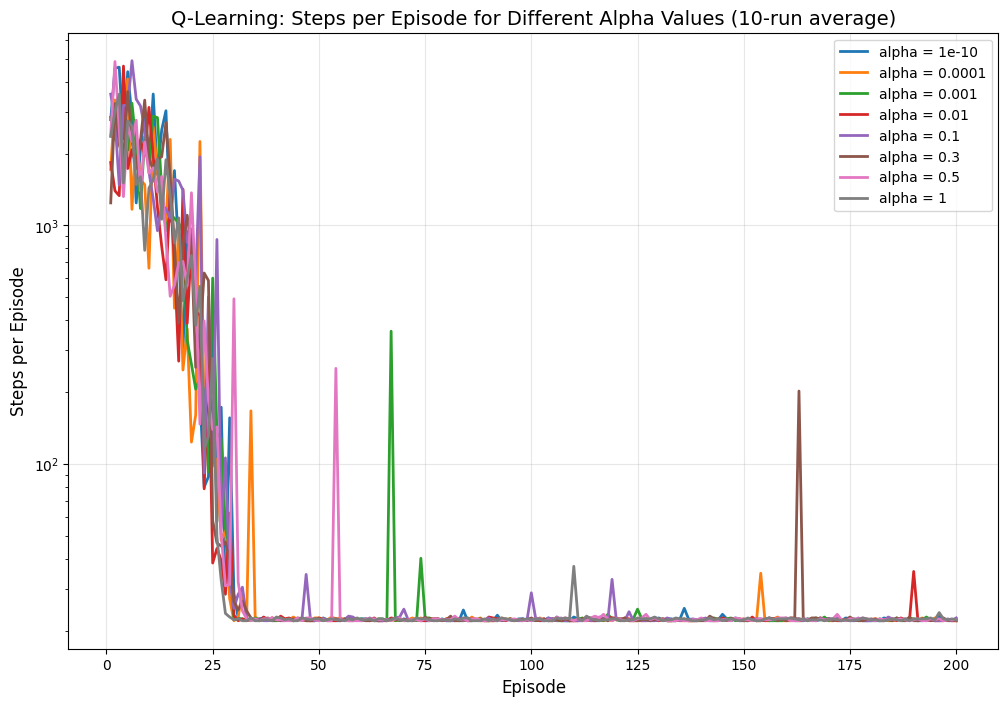

In [129]:
# Hyperparameters
n_runs = 10
n_episodes = 200
epsilon = 0.01
alpha_values = [1e-10, 0.0001, 0.001, 0.01, 0.1, 0.3, 0.5, 1]

results = {}

for alpha in tqdm(alpha_values):
    runs = run_agent(
        algorithm_class=QLearning,
        epsilon=epsilon,
        alpha=alpha,
        n_runs=n_runs,
        n_episodes=n_episodes,
        maze=maze
    )

    max_len = max(len(run) for run in runs)

    mean_steps = np.nanmean(runs, axis=0)
    std_steps = np.nanstd(runs, axis=0)

    results[alpha] = {
        'mean': mean_steps,
        'std': std_steps,
        'episodes': np.arange(1, len(mean_steps) + 1)
    }

plt.figure(figsize=(12, 8))

for i, (alpha, data) in enumerate(results.items()):
    plt.plot(data['episodes'], data['mean'],
             label=f"alpha = {alpha}",
             linewidth=2)

plt.xlabel("Episode", fontsize=12)
plt.ylabel("Steps per Episode", fontsize=12)
plt.yscale('log')
plt.title("Q-Learning: Steps per Episode for Different Alpha Values (10-run average)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we can see, the alpha value has little to no effect on learning. I suspect that this is due to the maze being too easy to solve, and the learning process arriving at the correct solution regardless of the learning rate.

### 2.3 Introducing More Rewards
#### Question 13

In [130]:
# Create a Maze instance.
maze = Maze("./../data/toy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_reward(x=9, y=0, reward=5)
maze.set_terminal(x=9, y=9)
maze.set_terminal(x=9, y=0)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)

# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []



  0%|          | 0/10 [00:00<?, ?it/s]

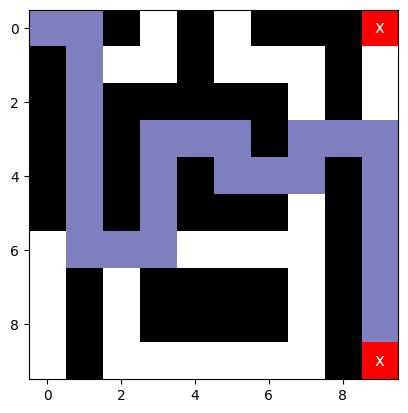

 10%|█         | 1/10 [00:00<00:02,  4.02it/s]

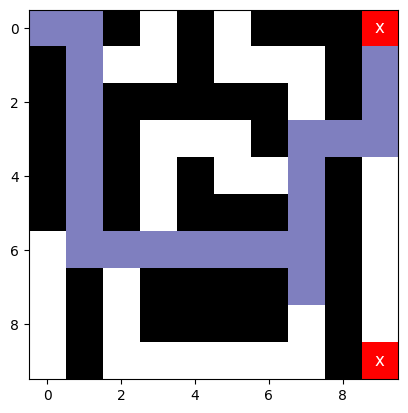

 20%|██        | 2/10 [00:00<00:01,  4.23it/s]

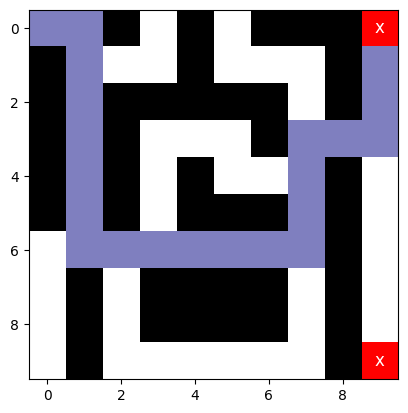

 30%|███       | 3/10 [00:00<00:01,  4.24it/s]

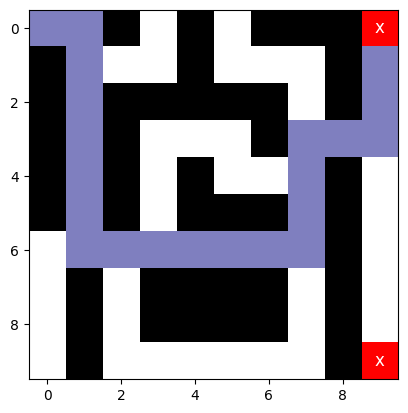

 40%|████      | 4/10 [00:00<00:01,  4.45it/s]

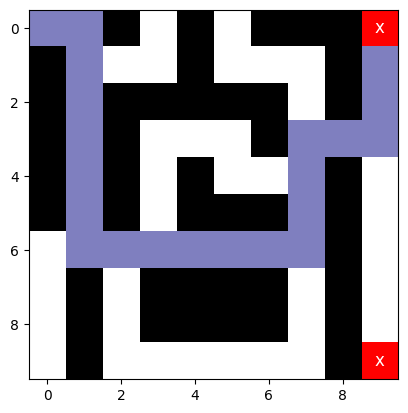

 50%|█████     | 5/10 [00:01<00:01,  4.80it/s]

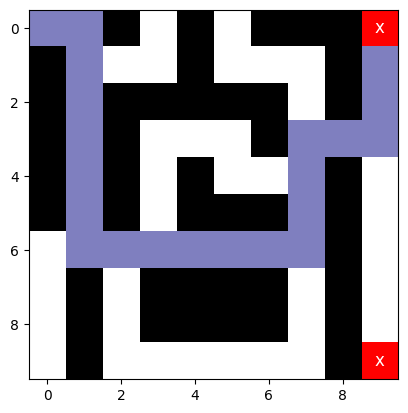

 60%|██████    | 6/10 [00:01<00:00,  4.87it/s]

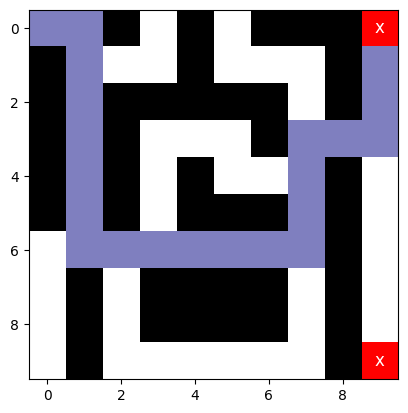

 70%|███████   | 7/10 [00:01<00:00,  4.94it/s]

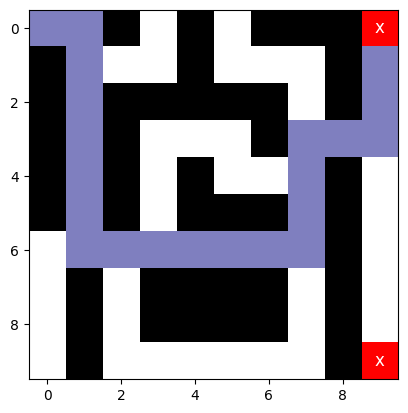

 80%|████████  | 8/10 [00:01<00:00,  4.79it/s]

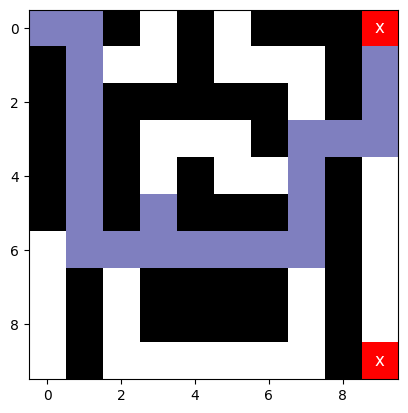

 90%|█████████ | 9/10 [00:01<00:00,  4.97it/s]

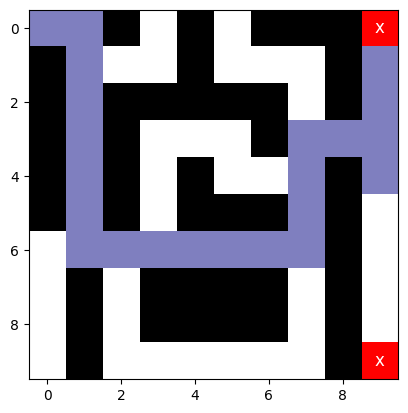

100%|██████████| 10/10 [00:02<00:00,  4.73it/s]

[10, 5, 5, 5, 5, 5, 5, 5, 5, 5]


In [131]:
# Hyperparameters
n_runs = 10
n_episodes = 250
epsilon = 0.1
alpha = 0.05

# Run the agent 10 times for each algorithm
runs_q = run_agent(
    algorithm_class=QLearning,
    maze=maze,
    epsilon=epsilon,
    alpha=alpha,
    n_runs=n_runs,
    n_episodes=n_episodes,
    show_path=True
)

The learning process almost always converges on the lesser reward!

#### Question 14

  0%|          | 0/10 [00:00<?, ?it/s]

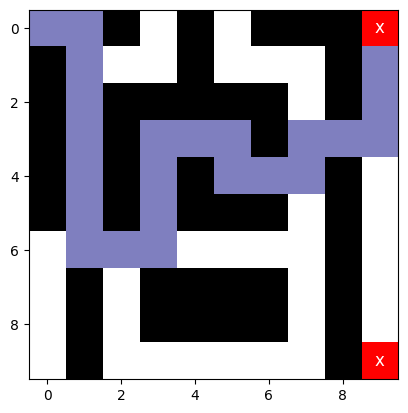

 10%|█         | 1/10 [00:00<00:01,  5.31it/s]

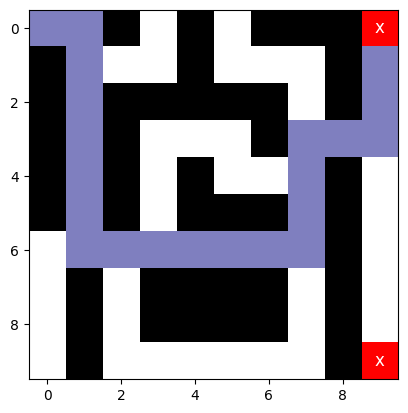

 20%|██        | 2/10 [00:00<00:01,  4.71it/s]

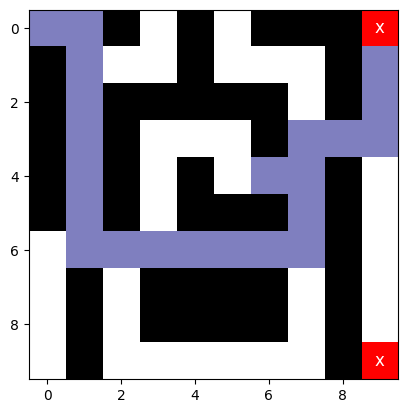

 30%|███       | 3/10 [00:00<00:01,  5.18it/s]

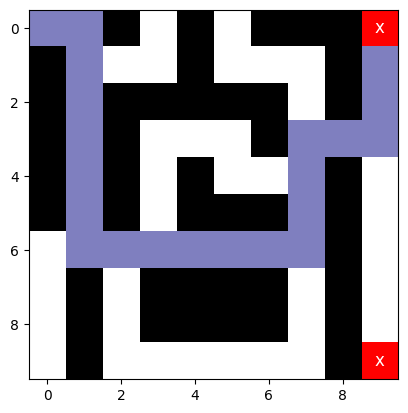

 40%|████      | 4/10 [00:00<00:01,  5.03it/s]

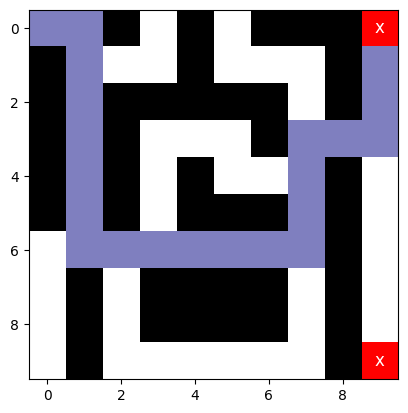

 50%|█████     | 5/10 [00:01<00:01,  4.62it/s]

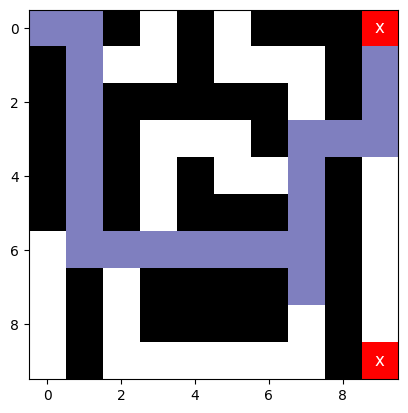

 60%|██████    | 6/10 [00:01<00:00,  4.77it/s]

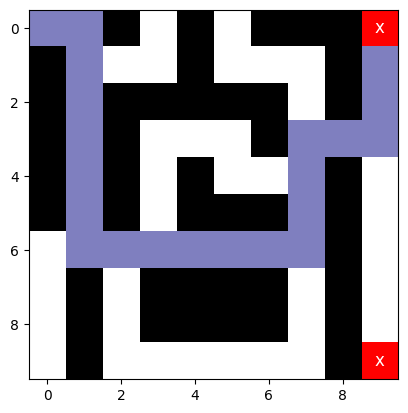

 70%|███████   | 7/10 [00:01<00:00,  5.00it/s]

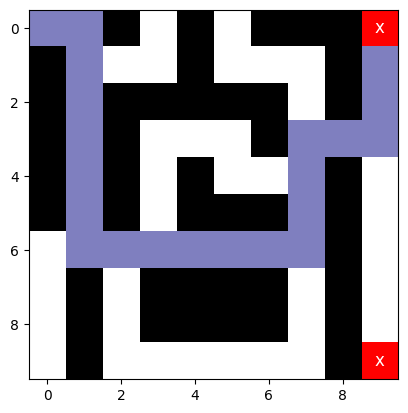

 80%|████████  | 8/10 [00:01<00:00,  4.68it/s]

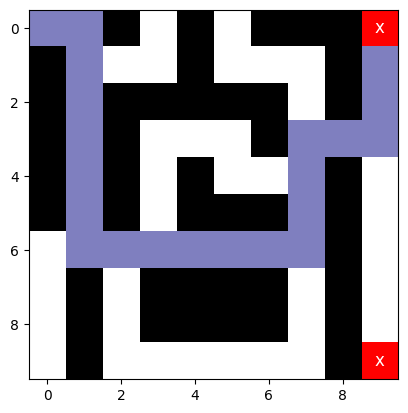

 90%|█████████ | 9/10 [00:01<00:00,  4.69it/s]

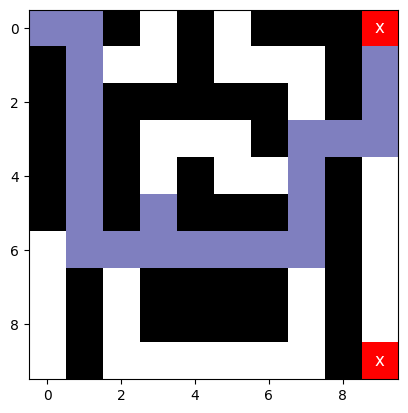

100%|██████████| 10/10 [00:02<00:00,  4.73it/s]

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


In [132]:
# Hyperparameters
n_runs = 10
n_episodes = 250
epsilon = 0.1
alpha = 0.05

# Run the agent 10 times for each algorithm
runs_q = run_agent(
    algorithm_class=SARSA,
    maze=maze,
    epsilon=epsilon,
    alpha=alpha,
    n_runs=n_runs,
    n_episodes=n_episodes,
    show_path=True
)

SARSA does not solve the problem

#### Question 15

In [133]:
def run_agent_decay(maze, algorithm_class, epsilon, alpha, epsilon_min=0.01, epsilon_decay=0.995, gamma=0.9, strict_explore_steps=0, n_runs=10, n_episodes=20, show_path=False):

    all_runs = []
    awards=[]

    for _ in tqdm(range(n_runs)):
        current_epsilon = epsilon

        # Fresh environment
        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(a) for a in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        explorer = ExplorationStrategy(q_table)

        learner = algorithm_class(q_table, {"lr": alpha, "gamma": gamma})

        steps_per_episode = []

        for i in range(n_episodes):
            path = []

            agent.reset()
            state = agent.get_state(maze)
            episode_steps = 0

            # SARSA needs next_action
            action = explorer.e_greedy(agent, maze, current_epsilon)

            while not state.done:
                path.append((state.y, state.x))

                next_state, reward, done = agent.step(action, maze)
                episode_steps += 1

                # Q-Learning
                if isinstance(learner, QLearning):
                    learner.learn(
                        actions,
                        state,
                        action,
                        next_state,
                        reward,
                        done
                    )
                    next_action = explorer.e_greedy(agent, maze, current_epsilon)

                # SARSA
                else:
                    next_action = explorer.e_greedy(agent, maze, current_epsilon)
                    learner.learn(
                        state,
                        action,
                        next_state,
                        next_action,
                        reward,
                        done
                    )

                state = next_state
                action = next_action

            steps_per_episode.append(episode_steps)
            if i >= strict_explore_steps:
                current_epsilon = max(epsilon_min, current_epsilon * epsilon_decay)

        if show_path:
            maze.visualize(path)
        all_runs.append(steps_per_episode)
        awards.append(maze.get_reward(state.x, state.y))

    print(awards)
    return all_runs


In [134]:
# Hyperparameters
n_runs = 10
n_episodes = 1000
epsilon = 1
epsilon_decay = 0.995
epsilon_min = 0.1
alpha = 0.05

# Run the agent 10 times for each algorithm
runs_q = run_agent_decay(
    algorithm_class=QLearning,
    maze=maze,
    epsilon=epsilon,
    alpha=alpha,
    epsilon_decay=epsilon_decay,
    epsilon_min=epsilon_min,
    strict_explore_steps=150,
    n_runs=n_runs,
    n_episodes=n_episodes
)

100%|██████████| 10/10 [00:10<00:00,  1.07s/it]

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


Implementing epsilon decay with a strict exploration phase fixed the problem. The agent first spends 150 episodes exploring randomly, and only then optimizes the route with a lower epsilon. This ensures the agent has discovered the 10 reward enough times to have a robust QTable. We get the best of both worlds: the thoroughness of a high epsilon and the optimization of a low epsilon.

**ADD PLOT AND LITERATure**

#### Question 16

In [135]:
# Hyperparameters
n_runs = 20
n_episodes = 1000
epsilon = 1
epsilon_decay = 0.995
epsilon_min = 0.1
alpha = 0.05

gamma_vals = [0.8, 0.81, 0.82, 0.83, 0.84, 0.85, ]

for gamma in gamma_vals:
    print(gamma)

    runs_q = run_agent_decay(
        algorithm_class=QLearning,
        maze=maze,
        epsilon=epsilon,
        alpha=alpha,
        epsilon_decay=epsilon_decay,
        epsilon_min=epsilon_min,
        strict_explore_steps=150,
        gamma=gamma,
        n_runs=n_runs,
        n_episodes=n_episodes
    )

0.8


100%|██████████| 20/20 [00:19<00:00,  1.00it/s]


[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
0.81


100%|██████████| 20/20 [00:20<00:00,  1.01s/it]


[5, 5, 10, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 10, 5, 5, 10]
0.82


...

[10, 10, 10, 10, 5, 10, 10, 10, 5, 10, 10, 10, 10, 5, 10, 10, 10, 10, 10, 10]
0.84


100%|██████████| 20/20 [00:23<00:00,  1.20s/it]


[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 5, 10, 10, 10, 10, 10, 5, 10]
0.85


100%|██████████| 20/20 [00:21<00:00,  1.06s/it]

[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


We see that below $\gamma = 0.83$ we start seeing some agents converge on the 5 reward, and below $\gamma = 0.81$ all agents converge on this reward.

From the intersection in the maze where you can go up for the 5 reward or down for the 10 reward, it is 3 steps towards the 5 reward and 6 steps towards the 10 reward. Therefore, we want to solve:

$$5\gamma^3 \gt 10\gamma^6$$
$$1 \gt 2\gamma^3$$
$$\gamma^3 \lt \frac{1}{2}$$
$$\gamma \lt \sqrt[3]{\frac{1}{2}} \approx 0.794$$

This aligns pretty well with our experimental values.

## 3. Open Questions
### 3.1 Reflection
#### Question 17

Give at least one downside of an algorithm that is greedy with its action selection.

The downside of an algorithm that is greedy with its action selection is that it would choose the best option from a known selection(exploitation) instead of taking a look around to potentially find better options(exploration). By always doing exploitation, you might get stuck in a local optimum instead of the global optimum.


#### Question 18

When and why can reward functions cause problems in society? Think in terms of agents “understanding” the point of their reward functions.

Reward functions can cause the following problem: the agents will understand that certain actions lead to rewards and stop doing other things than that action which is called Reward Hacking. An example would be an app which keeps track of how many steps you have taken in a day with you getting a reward when you have taken more than 5000 steps. The goal is of course to have a healthier society. The “hacking” action here would be to simply shake your phone without even taking a step. The app will increment the number of steps without you even taking a step. The agent will understand that the reward comes from the app sensing a vibration instead of actually taking a walk outside. So in the end, the society will be full of highly rewarded but unhealthy agents.


#### Question 19

Can you think of a way to overcome these problems for reward functions, used in practice?

To solve the problem given in question 17, we should introduce an algorithm called epsilon greedy which chooses the greedy approach with probability 1-$\epsilon$ and explores unknown regions with probability $\epsilon$. This prevents the algorithm from being stuck in a local optimum and looks for better alternatives if it exists.
To solve the problem given in question 18, we should introduce multi-dimensional rewarding functions. Going further with our example of the number of steps taken, we should also introduce distance traveled, tracked using GPS, and increase of heart rate measured by wearable sensors although this might introduce new privacy problems. This makes it harder to “hack” to maximize the reward.

By introducing these 2 solutions, we can create a model that looks for the best solution and follows the spirit of the experiment instead of purely maximizing the rewards.


### 3.2 Pen and Paper
#### Question 20

![Screenshot 2026-04-01 003329.png](<attachment:Screenshot 2026-04-01 003329.png>)

Draw a graph representing the transitions of the MDP for the story above. The nodes represent states, the arrows annotated with actions and probabilities represent the transitions between the states. Actions that lead to no change in the state of the robot can be omitted to avoid clutter. Make sure to name all states.

We have defined the following states:

| State name |  |
| -- | -- |
| Entrance Empty| START STATE |
| Entrance Apple| - |
| Entrance 1 Berry| - |
| Entrance 2 Berry| - |
| Aisle Empty | - |
| Aisle Apple| - |
| Aisle 1 Berry| - |
| Aisle 2 Berry| - |
| Checkout Empty | - |
| Checkout Apple| - |
| Checkout 1 Berry| - |
| Checkout 2 Berry| - |
| Payment | TERMINAL |

We assumed that "Whenever the robot is in the aisle, it can decide to move to the checkout and pay for the groceries it is holding; the payment always succeeds." meant we will move to checkout and after that we will pay, so 2 separate actions.

In the graph above, you see some places with 
| Variable | Value |
|--|--|
| R | 0 |
| P | 90% |
| A | forward/back |
| fail | -1 |

Those are the information for the edges connecting the states.
R stands for reward, P for probability, A for action and fail the penalty.
We have written forward and back actions to save space and for readability. Please see this as 2 distinct actions, going from entrance to aisle = forward and going from aisle to entrance = back. Same holds for aisle and checkout.

We have left out the invalid actions with its corresponding penalty of -1 as it leaves no change in state of the robot, picking up apples in the entrance will give you -1 point but you stay at the entrance, picking up berries after picking up apples is also not allowed but we have also left that out.

As you can see in the graph above, we have also omitted the self loops for failed actions like 10% fail for move and 20% fail for picking up 2nd box of berries, so we will verbally explain what will happen when your action failed. In case of failure, the robot will recieve the penalty listed under fail and stay in the same state. We have left the self loops out of the graph as otherwise the graph was very messy and hard to comprehend.
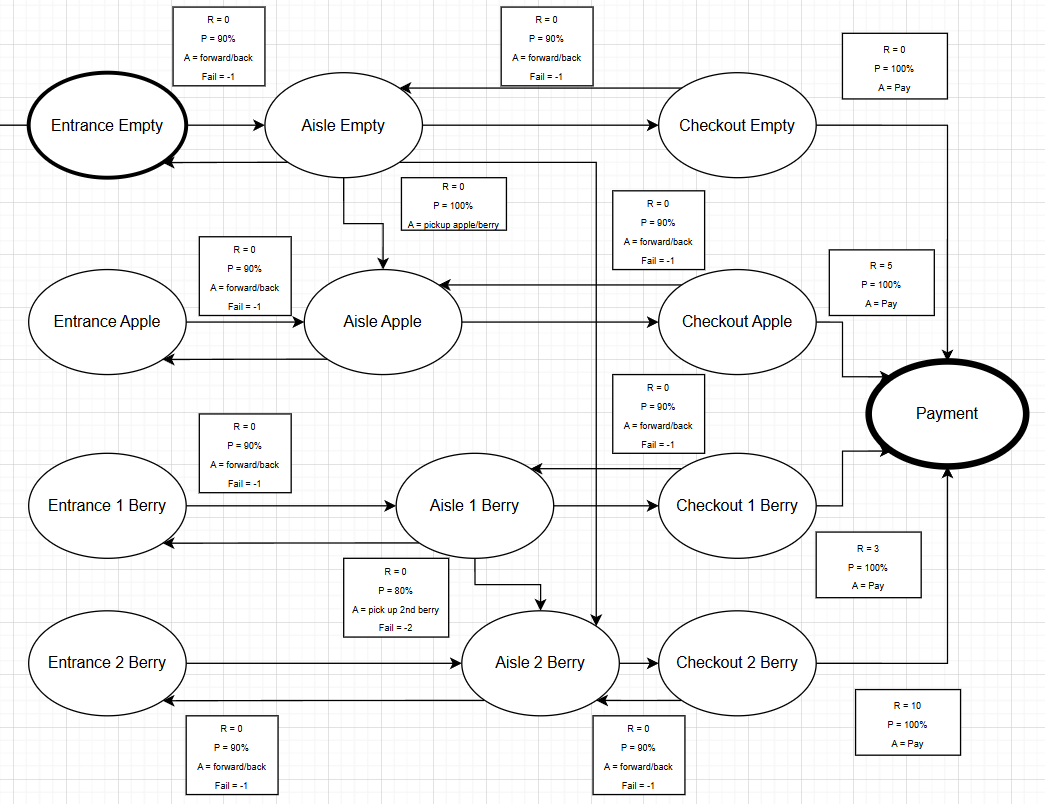

#### Question 21

During this question we have given our states the following names:<br>
S0 - entrance empty<br>
S1 - entrance apple<br>
S2 - entrance 1 berry<br>
S3 - entrance 2 berry<br>
A0 - aisle empty<br>
A1 - aisle apple<br>
A2 - aisle 1 berry<br>
A3 - aisle 2 berry<br>
C0 - checkout empty<br>
C1 - checkout apple<br>
C2 - checkout 1 berry<br>
C3 - checkout 2 berry<br>
P - payment<br>


The policy is “if you don't hold berries, then pick up berries”.
If you have 2 berries then go to checkout and pay.
Formula used for calculation => Vi(s) = summation of P(s’ | s,a) * [R(s,a,s’) + 0.9*Vi-1(s’)]

All states start with V0(s) = 0.<br>
REST = S0, S1, S2, A1, C0, C1, C2 = 0<br>
S3 = 0<br>
A0 = 0<br>
A2 = 0<br>
A3 = 0<br>
C3 = 0<br>
P = 0

V1(s)<br>
REST = 1\*(-1 + 0.9\*0) = -1 as pick up berries is an invalid action<br>
S3 = 1\*(-1 + 0.9\*0) = -1 as move to checkout is an invalid action<br>
A0 = 1\*(0 + 0.9\*0) = 0 as pick up berries goes to A2 which has value 0<br>
A2 = 0.8\*(0 + 0.9\*0) + 0.2\*(-2 + 0.9\*0) = -0.4<br>
A3 = 0.9\*(0 + 0.9\*0) + 0.1\*(-1 + 0.9\*0) = -0.1<br>
C3 = 1\*(10 + 0.9\*0) = 10<br>
P = 0

V2(s)<br>
REST = 1\*(-1 + 0.9\*-1) = -1.9 as pick up berries is still an invalid action<br>
S3 = 1\*(-1 + 0.9\*-1) = -1.9 as move to checkout is still an invalid action<br>
A0 = 1\*(0 + 0.9\*-0.4) = -0.36 as pick up berries goes to A2 which has value -0.4<br>
A2 = 0.8\*(0 + 0.9\*-0.1) + 0.2\*(-2 + 0.9\*-0.4) = -0.544<br>
A3 = 0.9\*(0 + 0.9\*10) + 0.1\*(-1 + 0.9\*-0.1) = 7.991<br>
C3 = 1\*(10 + 0.9\*0) = 10<br>
P = 0<br>


| State | k = 0 | k = 1 | k = 2 |
|-------|---|----|--------|
| Payment(terminal)     | 0 | 0    | 0     |
| Checkout 2 Berry     | 0 | 10   | 10     |
| Aisle 2 Berry     | 0 | -0.1 | 7.991  |
| Aisle 1 Berry | 0 | -0.4 | -0.544 |
| Aisle Empty    | 0 | 0    | -0.36 |
| Entrance 2 Berry    | 0 | -1   | -1.9  |
| REST    | 0 | -1   | -1.9  |

#### Question 22

We could determine the optimal policy for the robot by applying policy improvement. For each state, we evaluate all the possible actions instead of having a fixed policy like q21 using the Bellman Optimality Equation and we select the action with the highest expected reward. This procedure will automatically tell us which of the following, a bag of apples, 1 box of berries, 2 boxes of berries or not picking up any fruit will lead to the highest expected reward.

### 3.3 Division of Work

#### Question 23

|          Component          |  Kazuki  |  Jonah  |  Mauk  |  Satsuki  |
|-----------------------------|----------|---------|--------|-----------|
| Code (design)               |   25%    |   25%   |  25%   |    25%    |
| Code (implementation)       |   25%    |   25%   |  25%   |    25%    |
| Code (validation)           |   25%    |   25%   |  25%   |    25%    |
| Experiments (execution)     |   25%    |   25%   |  25%   |    25%    |
| Experiments (analysis)      |   25%    |   25%   |  25%   |    25%    |
| Experiments (visualization) |   25%    |   25%   |  25%   |    25%    |
| Report (original draft)     |   25%    |   25%   |  25%   |    25%    |
| Report (reviewing, editing) |   25%    |   25%   |  25%   |    25%    |

### References

AI disclaimer:

 - AI was used in this assignment to assist in improving the written answers in this report as well as to give us ideas on the implementations of the unit tests for validating our implementations.
 - All AI improved content has been read and understood by each team member.
 - The implementations of the algorithms, results and the ideas are our own.
 - AI was used to help rephrase our answers, not build the whole assignment from scratch